In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

Definition of functions using recursive formula

In [3]:
def phi(x): return norm.pdf(x)
def G(x): return 1 - norm.cdf(x)
def M(x): return phi(x) / G(x)

def I0(x): return G(x)
def I1(x): return phi(x) - x * G(x)
def I2(x): return (2 - 1) * I0(x) - x * I1(x)
def I3(x): return (3 - 1) * I1(x) - x * I2(x)
def I4(x): return (4 - 1) * I2(x) - x * I3(x)
def I5(x): return (5 - 1) * I3(x) - x * I4(x)
def I6(x): return (6 - 1) * I4(x) - x * I5(x)
def I7(x): return (7 - 1) * I5(x) - x * I6(x)

def f0(x, delta): return np.where(G(x) <= delta, x, 0)
def f1(x, delta): return x + (I1(x) / delta)**(1/1)
def f2(x, delta): return x + (I2(x) / delta)**(1/2)
def f3(x, delta): return x + (I3(x) / delta)**(1/3)
def f4(x, delta): return x + (I4(x) / delta)**(1/4)
def f5(x, delta): return x + (I5(x) / delta)**(1/5)
def f6(x, delta): return x + (I6(x) / delta)**(1/6)
def f7(x, delta): return x + (I7(x) / delta)**(1/7)
def finf(x, delta): return (np.log(1/delta) + x**2 / 2)/x

def f_subg(delta):return np.sqrt(2 *np.log(1/delta))
def g(delta):return norm.ppf(1-delta)


# Vanilla plot

/tmp/ipykernel_1123348/4197450367.py:22: RuntimeWarning: divide by zero encountered in divide
  def finf(x, delta): return (np.log(1/delta) + x**2 / 2)/x


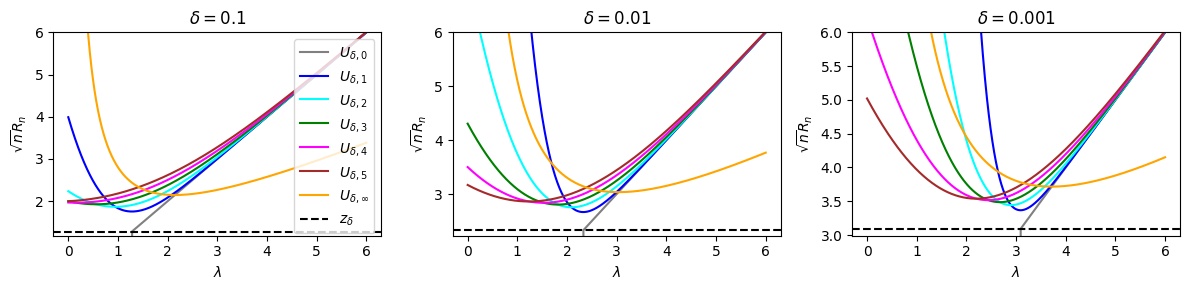

In [7]:
# deltas = [0.1, 0.05, 0.01, 0.005, 0.001, 0.0005, 0.0001, 0.00005, 0.00001]
# fig, axes = plt.subplots(3, 3, figsize=(10, 10))

deltas = [0.1, 0.01, 0.001]
fig, axes = plt.subplots(1, 3, figsize=(12, 3))

axes = axes.flatten()
x = np.linspace(0, 6, 1000)
epsilon = 10

for ax, delta in zip(axes, deltas):

    y = f0(x, delta)
    ax.plot(x, y, label=fr"$U_{{\delta, 0}}$", color='gray')
    
    y = f1(x, delta)
    ax.plot(x, y, label=fr"$U_{{\delta, 1}}$", color='blue')
    
    y = f2(x, delta)
    ax.plot(x, y, label=fr"$U_{{\delta, 2}}$", color='cyan')
    
    y = f3(x, delta)
    ax.plot(x, y, label=fr"$U_{{\delta, 3}}$", color='green')

    y = f4(x, delta)
    ax.plot(x, y, label=fr"$U_{{\delta, 4}}$", color='magenta')

    y = f5(x, delta)
    ax.plot(x, y, label=fr"$U_{{\delta, 5}}$", color='brown')
    
    y = finf(x, delta)
    ax.plot(x, y, label=fr"$U_{{\delta, \infty}}$", color='orange')
    
    # Optional sub-Gaussian line
    # ax.axhline(f_subg(delta), label="Sub-Gaussian bound", color='red', linestyle='--')
    
    ax.axhline(g(delta), label=fr"$z_{{\delta}}$", color='black', linestyle='--')

    
    ax.set_xlabel(r'$\lambda$')
    ax.set_ylabel(r'$\sqrt{n}R_n$')
    ax.set_title(rf"$\delta = {delta}$")
    ax.set_ylim(g(delta)-.1, f_subg(delta)+epsilon)
    ax.set_ylim(g(delta)-.1, 6)

axes[0].legend(loc = 'upper right')

plt.tight_layout()
plt.savefig(f"plots/bounds_plot.png", dpi=300)
plt.show()

# Post-hoc inference

vline 2 no red line

/tmp/ipykernel_1123348/4197450367.py:22: RuntimeWarning: divide by zero encountered in divide
  def finf(x, delta): return (np.log(1/delta) + x**2 / 2)/x


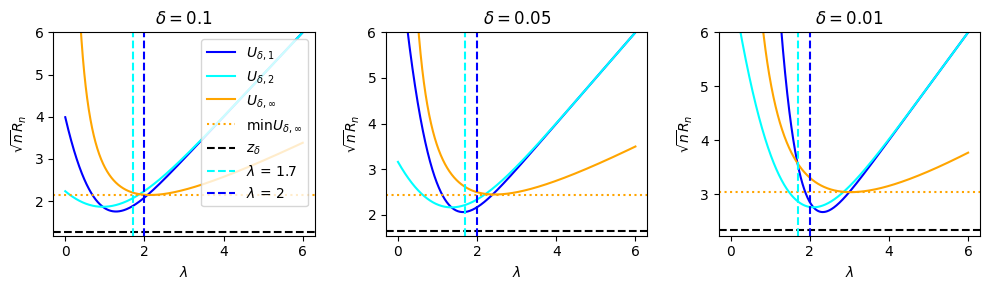

In [8]:
deltas = [0.1, 0.05, 0.01]
fig, axes = plt.subplots(1, 3, figsize=(10, 3))

axes = axes.flatten()
x = np.linspace(0, 6, 1000)
epsilon = 10

for ax, delta in zip(axes, deltas):
    
    y = f1(x, delta)
    ax.plot(x, y, label=fr"$U_{{\delta, 1}}$", color='blue')
    
    y = f2(x, delta)
    ax.plot(x, y, label=fr"$U_{{\delta, 2}}$", color='cyan')
    
    y_A = finf(x, delta)
    ax.plot(x, y_A, label=fr"$U_{{\delta, \infty}}$", color='orange')

    # --- NEW: Plot horizontal line at the minimum of A_delta on the grid ---
    # We slice with x > 0 to avoid the division by zero at x=0
    min_A = np.nanmin(y_A[x > 0])
    ax.axhline(min_A, label=r"$\min U_{{\delta, \infty}}$", color='orange', linestyle=':')
    # -----------------------------------------------------------------------
    
    # Optional sub-Gaussian line
    # ax.axhline(f_subg(delta), label="Sub-Gaussian bound", color='red', linestyle='--')
    
    ax.axhline(g(delta), label=fr"$z_{{\delta}}$", color='black', linestyle='--')

    vline = 1.7
    ax.axvline(vline, label=fr"$\lambda$ = {vline}", color='cyan', linestyle='--')

    vline = 2
    ax.axvline(vline, label=fr"$\lambda$ = {vline}", color='blue', linestyle='--')


    
    ax.set_xlabel(r'$\lambda$')
    ax.set_ylabel(r'$\sqrt{n}R_n$')
    ax.set_title(rf"$\delta = {delta}$")
    ax.set_ylim(g(delta)-.1, f_subg(delta)+epsilon)
    ax.set_ylim(g(delta)-.1, 6)

axes[0].legend(loc='upper right')

plt.tight_layout()
plt.savefig(f"plots/bounds_plot_posthoc_2.png", dpi=300)
plt.show()